# Business Clustering Optimization Experiments

## Objective
Find optimal clustering parameters for ALL cities in the dataset by testing:
- Multiple feature engineering approaches (business features + review embeddings)
- Multiple dimensionality reduction techniques (PCA, UMAP, raw)
- Multiple clustering algorithms (HDBSCAN, KMeans, GMM, Agglomerative)
- Comprehensive evaluation metrics (not just silhouette!)

## Memory-Efficient Strategy
1. **Phase 1**: Pre-aggregate review embeddings per business (run once)
2. **Phase 2**: Process each city independently (low memory)
3. **Phase 3**: Analyze results and generate recommendations

In [20]:
import numpy as np
import pandas as pd
import json
import ast
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Dimensionality reduction
from sklearn.decomposition import PCA, IncrementalPCA
from umap import UMAP

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
import hdbscan

# Metrics
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All imports loaded")

✓ All imports loaded


## Configuration

In [21]:
# Paths
BUSINESS_PATH = 'businesses_enriched.parquet'
REVIEW_EMBEDDINGS_PATH = 'review_embeddings.npy'
REVIEW_METADATA_PATH = 'review_metadata.parquet'
OUTPUT_DIR = Path('clustering_experiments')
OUTPUT_DIR.mkdir(exist_ok=True)

# Aggregated embeddings cache
BUSINESS_EMBEDDINGS_CACHE = OUTPUT_DIR / 'business_review_embeddings.parquet'

# Results
RESULTS_DIR = OUTPUT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# City size thresholds
LARGE_CITY_THRESHOLD = 500  # HDBSCAN recommended
MEDIUM_CITY_THRESHOLD = 100  # Test both HDBSCAN and KMeans
SMALL_CITY_THRESHOLD = 50   # KMeans or simple rules

print(f"✓ Output directory: {OUTPUT_DIR}")
print(f"✓ Results directory: {RESULTS_DIR}")

✓ Output directory: clustering_experiments
✓ Results directory: clustering_experiments\results


---
# PHASE 1: Pre-aggregate Review Embeddings
**Run this once to create cached business-level embeddings**

In [22]:
def aggregate_review_embeddings():
    """
    Aggregate review embeddings per business.
    Memory-efficient: processes in chunks.
    """
    print("="*80)
    print("AGGREGATING REVIEW EMBEDDINGS PER BUSINESS")
    print("="*80)
    
    # Check if cache exists
    if BUSINESS_EMBEDDINGS_CACHE.exists():
        print(f"✓ Cache found: {BUSINESS_EMBEDDINGS_CACHE}")
        response = input("Use cached embeddings? (y/n): ")
        if response.lower() == 'y':
            df = pd.read_parquet(BUSINESS_EMBEDDINGS_CACHE)
            print(f"✓ Loaded {len(df)} businesses from cache")
            return df
    
    print("\n1. Loading review metadata...")
    review_meta = pd.read_parquet(REVIEW_METADATA_PATH)
    print(f"   ✓ {len(review_meta):,} reviews loaded")
    print(f"   ✓ {review_meta['business_id'].nunique():,} unique businesses")
    
    print("\n2. Loading review embeddings (memory-mapped)...")
    embeddings = np.load(REVIEW_EMBEDDINGS_PATH, mmap_mode='r')
    print(f"   ✓ Shape: {embeddings.shape}")
    
    print("\n3. Aggregating per business...")
    results = []
    
    for business_id, group in tqdm(review_meta.groupby('business_id'), desc="Processing"):
        indices = group.index.values
        business_embeddings = embeddings[indices]
        
        # Compute statistics
        mean_emb = business_embeddings.mean(axis=0)
        std_emb = business_embeddings.std(axis=0)
        
        results.append({
            'business_id': business_id,
            'review_count': len(indices),
            'embedding_mean': mean_emb,
            'embedding_std': std_emb
        })
    
    df = pd.DataFrame(results)
    
    print(f"\n4. Saving to cache...")
    df.to_parquet(BUSINESS_EMBEDDINGS_CACHE, index=False)
    print(f"   ✓ Saved: {BUSINESS_EMBEDDINGS_CACHE}")
    
    file_size_mb = BUSINESS_EMBEDDINGS_CACHE.stat().st_size / 1024 / 1024
    print(f"   ✓ File size: {file_size_mb:.2f} MB")
    
    print("\n" + "="*80)
    print("✓ AGGREGATION COMPLETE")
    print("="*80)
    
    return df

In [23]:
# Run aggregation
business_embeddings = aggregate_review_embeddings()

AGGREGATING REVIEW EMBEDDINGS PER BUSINESS

1. Loading review metadata...
   ✓ 2,516,821 reviews loaded
   ✓ 8,078 unique businesses

2. Loading review embeddings (memory-mapped)...
   ✓ Shape: (2516821, 384)

3. Aggregating per business...


Processing: 100%|██████████| 8078/8078 [02:00<00:00, 66.99it/s]  



4. Saving to cache...
   ✓ Saved: clustering_experiments\business_review_embeddings.parquet
   ✓ File size: 25.06 MB

✓ AGGREGATION COMPLETE


---
# PHASE 2: Feature Engineering Functions

In [24]:
def parse_nested_attributes(attr_dict):
    """
    Parse nested JSON-like attributes into flat features.
    """
    if not attr_dict or not isinstance(attr_dict, dict):
        return {}
    
    flat_attrs = {}
    
    for key, value in attr_dict.items():
        if value is None:
            continue
            
        # Handle string representations of dicts/lists
        if isinstance(value, str):
            if value in ['True', 'true']:
                flat_attrs[key] = 1
            elif value in ['False', 'false']:
                flat_attrs[key] = 0
            elif value.startswith('{') or value.startswith('['):
                try:
                    parsed = ast.literal_eval(value)
                    if isinstance(parsed, dict):
                        for sub_key, sub_val in parsed.items():
                            if isinstance(sub_val, bool):
                                flat_attrs[f"{key}_{sub_key}"] = int(sub_val)
                            elif sub_val is True:
                                flat_attrs[f"{key}_{sub_key}"] = 1
                            elif sub_val is False:
                                flat_attrs[f"{key}_{sub_key}"] = 0
                except:
                    pass
            elif value.startswith("u'") or value.startswith("'"):
                # Categorical - store as string for later one-hot encoding
                flat_attrs[key] = value.strip("u'").strip("'")
        elif isinstance(value, (int, float)):
            flat_attrs[key] = value
    
    return flat_attrs


def extract_business_features(city_businesses):
    """
    Extract and engineer business features using high-coverage attributes.
    Based on attribute analysis: focus on >=80% coverage attributes.
    
    High-coverage attributes (>=80%):
    - BusinessParking, RestaurantsTakeOut, RestaurantsDelivery, OutdoorSeating
    - BusinessAcceptsCreditCards, RestaurantsPriceRange2, HasTV, Ambience
    - WiFi, Alcohol, RestaurantsReservations, Caters, RestaurantsGoodForGroups
    - BikeParking, NoiseLevel, GoodForKids, GoodForMeal, RestaurantsAttire
    """
    features = city_businesses.copy()

    # Numerical features from enriched data
    numerical_cols = [
        'latitude', 'longitude', 'stars', 'review_count', 'photo_count',
        'avg_sentiment_score', 'avg_sentiment_prob_diff', 'avg_review_stars',
        'sentiment_volatility', 'business_age_days', 'review_velocity',
        'competitive_position_rating', 'competitive_position_sentiment'
    ]

    numerical_features = features[[col for col in numerical_cols if col in features.columns]].fillna(0)

    # High-coverage attributes (>=80% coverage from analysis)
    high_coverage_attrs = [
        'BusinessParking', 'RestaurantsTakeOut', 'RestaurantsDelivery',
        'OutdoorSeating', 'BusinessAcceptsCreditCards', 'RestaurantsPriceRange2',
        'HasTV', 'Ambience', 'WiFi', 'Alcohol', 'RestaurantsReservations',
        'Caters', 'RestaurantsGoodForGroups', 'BikeParking', 'NoiseLevel',
        'GoodForKids', 'GoodForMeal', 'RestaurantsAttire'
    ]

    # Parse attributes
    if 'attributes' in features.columns:
        parsed_attrs = []
        for _, row in features.iterrows():
            attrs = row['attributes']
            if isinstance(attrs, str):
                try:
                    attrs = ast.literal_eval(attrs)
                except:
                    attrs = {}

            # Extract only high-coverage attributes
            if isinstance(attrs, dict):
                filtered_attrs = {k: v for k, v in attrs.items() if k in high_coverage_attrs}
            else:
                filtered_attrs = {}

            parsed_attrs.append(parse_nested_attributes(filtered_attrs))

        attr_df = pd.DataFrame(parsed_attrs, index=features.index)

        # Convert to numeric where possible
        attr_numeric = attr_df.select_dtypes(include=[np.number]).fillna(0)

        # Handle categorical attributes (one-hot encode if few unique values)
        attr_categorical = attr_df.select_dtypes(include=['object'])
        if len(attr_categorical.columns) > 0:
            # One-hot encode categorical with few unique values (<10)
            for col in attr_categorical.columns:
                if attr_categorical[col].nunique() < 10 and attr_categorical[col].nunique() > 1:
                    dummies = pd.get_dummies(attr_categorical[col], prefix=col, drop_first=True)
                    attr_numeric = pd.concat([attr_numeric, dummies], axis=1)

        # Combine all features
        all_features = pd.concat([numerical_features, attr_numeric], axis=1)
    else:
        all_features = numerical_features

    return all_features


def prepare_feature_variants(city_businesses, city_embeddings):
    """
    Prepare multiple feature engineering variants to test.
    Returns dict of {variant_name: feature_matrix}
    """
    variants = {}
    
    # 1. Business features only
    business_features = extract_business_features(city_businesses)
    scaler = StandardScaler()
    business_scaled = scaler.fit_transform(business_features)
    variants['business_only'] = business_scaled
    
    # Merge embeddings
    merged = city_businesses[['business_id']].merge(
        city_embeddings, on='business_id', how='left'
    )
    
    # 2. Review embeddings only - mean
    if 'embedding_mean' in merged.columns:
        emb_mean = np.vstack(merged['embedding_mean'].fillna(
            lambda: np.zeros(384)
        ).values)
        variants['embedding_mean_only'] = emb_mean
        
        # 3. Review embeddings - mean + std
        if 'embedding_std' in merged.columns:
            emb_std = np.vstack(merged['embedding_std'].fillna(
                lambda: np.zeros(384)
            ).values)
            emb_combined = np.hstack([emb_mean, emb_std])
            variants['embedding_mean_std'] = emb_combined
        
        # 4. Business + embedding mean
        variants['business_plus_embedding_mean'] = np.hstack([
            business_scaled, emb_mean
        ])
        
        # 5. Business + embedding mean+std
        if 'embedding_std' in merged.columns:
            variants['business_plus_embedding_mean_std'] = np.hstack([
                business_scaled, emb_combined
            ])
    
    return variants

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


---
# PHASE 3: Dimensionality Reduction Functions

In [25]:
def apply_dimensionality_reduction(features, method_configs):
    """
    Apply various dimensionality reduction techniques.
    
    Args:
        features: numpy array of features
        method_configs: list of dicts with {'method': str, 'params': dict}
    
    Returns:
        dict of {config_name: reduced_features}
    """
    results = {}
    results['raw'] = features  # Always include raw features
    
    for config in method_configs:
        method = config['method']
        params = config.get('params', {})
        
        try:
            if method == 'pca':
                n_components = params.get('n_components', 50)
                n_components = min(n_components, features.shape[0]-1, features.shape[1])
                
                reducer = PCA(n_components=n_components, random_state=42)
                reduced = reducer.fit_transform(features)
                
                config_name = f"pca_{n_components}"
                results[config_name] = reduced
                
            elif method == 'umap':
                n_neighbors = params.get('n_neighbors', 15)
                n_components = params.get('n_components', 50)
                min_dist = params.get('min_dist', 0.1)
                metric = params.get('metric', 'euclidean')
                
                # Adjust for small datasets
                n_neighbors = min(n_neighbors, features.shape[0] - 1)
                n_components = min(n_components, features.shape[0] - 1, features.shape[1])
                
                reducer = UMAP(
                    n_neighbors=n_neighbors,
                    n_components=n_components,
                    min_dist=min_dist,
                    metric=metric,
                    random_state=42
                )
                reduced = reducer.fit_transform(features)
                
                config_name = f"umap_n{n_neighbors}_c{n_components}_d{min_dist}_{metric}"
                results[config_name] = reduced
                
        except Exception as e:
            print(f"   ⚠ Skipped {method} with {params}: {e}")
            continue
    
    return results

print("✓ Dimensionality reduction functions defined")

✓ Dimensionality reduction functions defined


---
# PHASE 4: Clustering Functions

In [26]:
def cluster_hdbscan(features, params):
    """
    Cluster using HDBSCAN.
    """
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=params.get('min_cluster_size', 10),
        min_samples=params.get('min_samples', 5),
        cluster_selection_epsilon=params.get('cluster_selection_epsilon', 0.0),
        cluster_selection_method=params.get('cluster_selection_method', 'eom'),
        metric=params.get('metric', 'euclidean')
    )
    
    labels = clusterer.fit_predict(features)
    
    return {
        'labels': labels,
        'probabilities': clusterer.probabilities_,
        'outlier_scores': clusterer.outlier_scores_,
        'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
        'noise_ratio': (labels == -1).sum() / len(labels),
        'clusterer': clusterer
    }


def cluster_kmeans(features, params):
    """
    Cluster using KMeans.
    """
    n_clusters = params.get('n_clusters', 5)
    n_clusters = min(n_clusters, features.shape[0] - 1)  # Ensure valid k
    
    clusterer = KMeans(
        n_clusters=n_clusters,
        n_init=50,
        random_state=42
    )
    
    labels = clusterer.fit_predict(features)
    
    return {
        'labels': labels,
        'n_clusters': n_clusters,
        'inertia': clusterer.inertia_,
        'clusterer': clusterer
    }


def cluster_gmm(features, params):
    """
    Cluster using Gaussian Mixture Model.
    """
    n_components = params.get('n_components', 5)
    n_components = min(n_components, features.shape[0] - 1)
    
    clusterer = GaussianMixture(
        n_components=n_components,
        covariance_type=params.get('covariance_type', 'full'),
        random_state=42
    )
    
    labels = clusterer.fit_predict(features)
    
    return {
        'labels': labels,
        'n_clusters': n_components,
        'bic': clusterer.bic(features),
        'aic': clusterer.aic(features),
        'clusterer': clusterer
    }


def cluster_agglomerative(features, params):
    """
    Cluster using Agglomerative Clustering.
    """
    n_clusters = params.get('n_clusters', 5)
    n_clusters = min(n_clusters, features.shape[0] - 1)
    
    clusterer = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=params.get('linkage', 'ward')
    )
    
    labels = clusterer.fit_predict(features)
    
    return {
        'labels': labels,
        'n_clusters': n_clusters,
        'clusterer': clusterer
    }

print("✓ Clustering functions defined")

✓ Clustering functions defined


---
# PHASE 5: Evaluation Metrics

In [27]:
def compute_cluster_metrics(features, labels, city_size):
    """
    Compute comprehensive cluster quality metrics.
    """
    metrics = {}
    
    # Filter out noise points for HDBSCAN
    valid_mask = labels >= 0
    valid_features = features[valid_mask]
    valid_labels = labels[valid_mask]
    
    n_clusters = len(set(valid_labels))
    noise_ratio = (~valid_mask).sum() / len(labels)
    
    metrics['n_clusters'] = n_clusters
    metrics['noise_ratio'] = noise_ratio
    metrics['n_valid_samples'] = len(valid_labels)
    
    # Need at least 2 clusters and reasonable samples
    if n_clusters < 2 or len(valid_labels) < 10:
        metrics['silhouette'] = -1
        metrics['davies_bouldin'] = np.inf
        metrics['calinski_harabasz'] = 0
        metrics['validity'] = False
        return metrics
    
    metrics['validity'] = True
    
    # Silhouette Score
    try:
        metrics['silhouette'] = silhouette_score(valid_features, valid_labels)
    except:
        metrics['silhouette'] = -1
    
    # Davies-Bouldin Index (lower is better)
    try:
        metrics['davies_bouldin'] = davies_bouldin_score(valid_features, valid_labels)
    except:
        metrics['davies_bouldin'] = np.inf
    
    # Calinski-Harabasz Score (higher is better)
    try:
        metrics['calinski_harabasz'] = calinski_harabasz_score(valid_features, valid_labels)
    except:
        metrics['calinski_harabasz'] = 0
    
    # Cluster size statistics
    cluster_sizes = pd.Series(valid_labels).value_counts().sort_index()
    metrics['cluster_sizes'] = cluster_sizes.tolist()
    metrics['min_cluster_size'] = cluster_sizes.min()
    metrics['max_cluster_size'] = cluster_sizes.max()
    metrics['mean_cluster_size'] = cluster_sizes.mean()
    metrics['cluster_size_std'] = cluster_sizes.std()
    
    # Balance score (penalize very imbalanced clusters)
    size_cv = metrics['cluster_size_std'] / metrics['mean_cluster_size'] if metrics['mean_cluster_size'] > 0 else np.inf
    metrics['cluster_balance'] = 1 / (1 + size_cv)  # 0-1, higher is better
    
    # Separation metric (minimum distance between centroids)
    try:
        centroids = []
        for label in set(valid_labels):
            cluster_points = valid_features[valid_labels == label]
            centroids.append(cluster_points.mean(axis=0))
        
        if len(centroids) >= 2:
            centroid_distances = cdist(centroids, centroids)
            np.fill_diagonal(centroid_distances, np.inf)
            metrics['min_centroid_distance'] = centroid_distances.min()
            metrics['mean_centroid_distance'] = centroid_distances[centroid_distances != np.inf].mean()
        else:
            metrics['min_centroid_distance'] = 0
            metrics['mean_centroid_distance'] = 0
    except:
        metrics['min_centroid_distance'] = 0
        metrics['mean_centroid_distance'] = 0
    
    # Composite score (weighted combination)
    # Normalize metrics to 0-1 range
    silhouette_norm = (metrics['silhouette'] + 1) / 2  # -1 to 1 -> 0 to 1
    db_norm = max(0, 1 - metrics['davies_bouldin'] / 10)  # Lower is better
    ch_norm = min(1, metrics['calinski_harabasz'] / 1000)  # Higher is better
    
    # Penalize extreme noise and imbalance
    noise_penalty = 1 - metrics['noise_ratio']
    balance_score = metrics['cluster_balance']
    
    # Weighted composite
    metrics['composite_score'] = (
        0.25 * silhouette_norm +
        0.20 * db_norm +
        0.20 * ch_norm +
        0.20 * noise_penalty +
        0.15 * balance_score
    )
    
    return metrics

print("✓ Evaluation metrics functions defined")

✓ Evaluation metrics functions defined


---
# PHASE 6: Experiment Runner

In [28]:
def get_clustering_configs(city_size, n_samples):
    """
    Get clustering configurations based on city size.
    """
    configs = []
    
    if city_size == 'large':  # >= 500
        # HDBSCAN grid
        for min_cluster_size in [10, 20, 30, 50]:
            for min_samples in [3, 5, 10]:
                for epsilon in [0.0, 0.1, 0.3]:
                    configs.append({
                        'method': 'hdbscan',
                        'params': {
                            'min_cluster_size': min_cluster_size,
                            'min_samples': min_samples,
                            'cluster_selection_epsilon': epsilon,
                            'metric': 'euclidean'
                        }
                    })
        
        # KMeans for comparison
        for k in [5, 8, 10, 12, 15, 20]:
            configs.append({
                'method': 'kmeans',
                'params': {'n_clusters': k}
            })
        
        # GMM
        for k in [5, 8, 10, 12, 15]:
            configs.append({
                'method': 'gmm',
                'params': {'n_components': k, 'covariance_type': 'full'}
            })
    
    elif city_size == 'medium':  # 100-499
        # HDBSCAN
        for min_cluster_size in [5, 10, 15, 20]:
            for min_samples in [3, 5]:
                configs.append({
                    'method': 'hdbscan',
                    'params': {
                        'min_cluster_size': min_cluster_size,
                        'min_samples': min_samples,
                        'cluster_selection_epsilon': 0.0
                    }
                })
        
        # KMeans
        for k in [3, 4, 5, 6, 8, 10]:
            configs.append({
                'method': 'kmeans',
                'params': {'n_clusters': k}
            })
        
        # GMM
        for k in [3, 5, 8]:
            configs.append({
                'method': 'gmm',
                'params': {'n_components': k}
            })
    
    elif city_size == 'small':  # 50-99
        # Primarily KMeans
        for k in [2, 3, 4, 5, 6, 8]:
            configs.append({
                'method': 'kmeans',
                'params': {'n_clusters': k}
            })
        
        # Try HDBSCAN with small params
        for min_cluster_size in [5, 10]:
            configs.append({
                'method': 'hdbscan',
                'params': {
                    'min_cluster_size': min_cluster_size,
                    'min_samples': 3
                }
            })
        
        # Agglomerative
        for k in [2, 3, 4, 5]:
            configs.append({
                'method': 'agglomerative',
                'params': {'n_clusters': k, 'linkage': 'ward'}
            })
    
    else:  # tiny < 50
        # Simple KMeans
        for k in [2, 3, 4]:
            configs.append({
                'method': 'kmeans',
                'params': {'n_clusters': min(k, n_samples-1)}
            })
    
    return configs


def get_dimred_configs(city_size, n_features):
    """
    Get dimensionality reduction configurations.
    """
    configs = []
    
    if city_size in ['large', 'medium']:
        # PCA variants
        for n_comp in [50, 100, 150, 200]:
            if n_comp < n_features:
                configs.append({
                    'method': 'pca',
                    'params': {'n_components': n_comp}
                })
        
        # UMAP variants
        for n_neighbors in [10, 15, 30]:
            for n_comp in [20, 50, 100]:
                for min_dist in [0.0, 0.1, 0.3]:
                    if n_comp < n_features:
                        configs.append({
                            'method': 'umap',
                            'params': {
                                'n_neighbors': n_neighbors,
                                'n_components': n_comp,
                                'min_dist': min_dist,
                                'metric': 'euclidean'
                            }
                        })
    
    elif city_size == 'small':
        # Simpler configs
        for n_comp in [20, 50]:
            if n_comp < n_features:
                configs.append({
                    'method': 'pca',
                    'params': {'n_components': n_comp}
                })
        
        configs.append({
            'method': 'umap',
            'params': {
                'n_neighbors': 10,
                'n_components': 20,
                'min_dist': 0.1
            }
        })
    
    return configs

print("✓ Experiment configuration functions defined")

✓ Experiment configuration functions defined


In [29]:
def run_city_experiments(city_name, city_businesses, city_embeddings, city_size):
    """
    Run all experiments for a single city.
    """
    print(f"\n{'='*80}")
    print(f"CITY: {city_name} ({city_size.upper()})")
    print(f"Businesses: {len(city_businesses)}")
    print(f"{'='*80}\n")
    
    results = []
    
    # 1. Prepare feature variants
    print("1. Preparing feature variants...")
    feature_variants = prepare_feature_variants(city_businesses, city_embeddings)
    print(f"   ✓ Created {len(feature_variants)} feature variants")
    
    # 2. For each feature variant
    for feat_name, features in feature_variants.items():
        print(f"\n2. Processing: {feat_name} (shape: {features.shape})")
        
        # Get dimensionality reduction configs
        dimred_configs = get_dimred_configs(city_size, features.shape[1])
        
        # Apply dimensionality reduction
        print(f"   → Testing {len(dimred_configs)+1} dim reduction configs...")
        reduced_variants = apply_dimensionality_reduction(features, dimred_configs)
        
        # 3. For each reduced variant
        for dimred_name, reduced_features in reduced_variants.items():
            print(f"     → {dimred_name} (shape: {reduced_features.shape})")
            
            # Get clustering configs
            clustering_configs = get_clustering_configs(city_size, len(reduced_features))
            
            # 4. For each clustering config
            for cluster_config in tqdm(clustering_configs, desc=f"       Clustering", leave=False):
                method = cluster_config['method']
                params = cluster_config['params']
                
                try:
                    # Cluster
                    if method == 'hdbscan':
                        cluster_result = cluster_hdbscan(reduced_features, params)
                    elif method == 'kmeans':
                        cluster_result = cluster_kmeans(reduced_features, params)
                    elif method == 'gmm':
                        cluster_result = cluster_gmm(reduced_features, params)
                    elif method == 'agglomerative':
                        cluster_result = cluster_agglomerative(reduced_features, params)
                    else:
                        continue
                    
                    # Evaluate
                    metrics = compute_cluster_metrics(
                        reduced_features,
                        cluster_result['labels'],
                        city_size
                    )
                    
                    # Store result
                    result = {
                        'city': city_name,
                        'city_size': city_size,
                        'n_businesses': len(city_businesses),
                        'feature_variant': feat_name,
                        'feature_dim': features.shape[1],
                        'dimred': dimred_name,
                        'reduced_dim': reduced_features.shape[1],
                        'clustering_method': method,
                        'clustering_params': json.dumps(params),
                        **metrics
                    }
                    
                    results.append(result)
                    
                except Exception as e:
                    print(f"         ⚠ Error: {e}")
                    continue
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Save results
    output_file = RESULTS_DIR / f"{city_name.replace(' ', '_')}_results.csv"
    results_df.to_csv(output_file, index=False)
    
    print(f"\n{'='*80}")
    print(f"✓ COMPLETED {city_name}")
    print(f"✓ Tested {len(results)} configurations")
    print(f"✓ Saved: {output_file}")
    print(f"{'='*80}")
    
    return results_df

print("✓ City experiment runner defined")

✓ City experiment runner defined


---
# PHASE 7: Run Experiments on All Cities

In [30]:
# Load businesses
print("Loading businesses data...")
businesses = pd.read_parquet(BUSINESS_PATH)
print(f"✓ Loaded {len(businesses)} businesses")

# Analyze city sizes
city_counts = businesses.groupby('city').size().sort_values(ascending=False)

cities_large = city_counts[city_counts >= LARGE_CITY_THRESHOLD].index.tolist()
cities_medium = city_counts[
    (city_counts >= MEDIUM_CITY_THRESHOLD) & 
    (city_counts < LARGE_CITY_THRESHOLD)
].index.tolist()
cities_small = city_counts[
    (city_counts >= SMALL_CITY_THRESHOLD) & 
    (city_counts < MEDIUM_CITY_THRESHOLD)
].index.tolist()
cities_tiny = city_counts[city_counts < SMALL_CITY_THRESHOLD].index.tolist()

print(f"\nCity Distribution:")
print(f"  Large (>={LARGE_CITY_THRESHOLD}): {len(cities_large)} cities")
print(f"  Medium ({MEDIUM_CITY_THRESHOLD}-{LARGE_CITY_THRESHOLD-1}): {len(cities_medium)} cities")
print(f"  Small ({SMALL_CITY_THRESHOLD}-{MEDIUM_CITY_THRESHOLD-1}): {len(cities_small)} cities")
print(f"  Tiny (<{SMALL_CITY_THRESHOLD}): {len(cities_tiny)} cities")

Loading businesses data...
✓ Loaded 8078 businesses

City Distribution:
  Large (>=500): 5 cities
  Medium (100-499): 9 cities
  Small (50-99): 7 cities
  Tiny (<50): 353 cities


In [31]:
# Select cities to process
# Start with representative sample, then expand

# Process all large cities (most important)
cities_to_process = [
    (city, 'large') for city in cities_large
]

# Process all medium cities
cities_to_process += [
    (city, 'medium') for city in cities_medium
]

# Process all small cities
cities_to_process += [
    (city, 'small') for city in cities_small
]

# Sample some tiny cities (10 representative ones)
import random
random.seed(42)
sampled_tiny = random.sample(cities_tiny, min(10, len(cities_tiny)))
cities_to_process += [
    (city, 'tiny') for city in sampled_tiny
]

print(f"\nTotal cities to process: {len(cities_to_process)}")
print(f"\nFirst 10: {[c[0] for c in cities_to_process[:10]]}")


Total cities to process: 31

First 10: ['Philadelphia', 'New Orleans', 'Tampa', 'Nashville', 'Indianapolis', 'St. Louis', 'Tucson', 'Reno', 'Santa Barbara', 'Edmonton']


In [32]:
# Run experiments
print("\n" + "="*80)
print("STARTING EXPERIMENTS")
print("="*80)

all_results = []

for city_name, city_size in tqdm(cities_to_process, desc="Cities"):
    try:
        # Filter businesses for this city
        city_businesses = businesses[businesses['city'] == city_name].copy()
        
        # Get embeddings for these businesses
        city_embeddings_subset = business_embeddings[
            business_embeddings['business_id'].isin(city_businesses['business_id'])
        ].copy()
        
        # Run experiments
        city_results = run_city_experiments(
            city_name,
            city_businesses,
            city_embeddings_subset,
            city_size
        )
        
        all_results.append(city_results)
        
        # Clear memory
        del city_businesses, city_embeddings_subset, city_results
        
    except Exception as e:
        print(f"\n⚠ ERROR processing {city_name}: {e}")
        continue

print("\n" + "="*80)
print("✓ ALL EXPERIMENTS COMPLETE")
print("="*80)


STARTING EXPERIMENTS


Cities:   0%|          | 0/31 [00:00<?, ?it/s]


CITY: Philadelphia (LARGE)
Businesses: 1046

1. Preparing feature variants...
   ✓ Created 5 feature variants

2. Processing: business_only (shape: (1046, 52))
   → Testing 20 dim reduction configs...
     → raw (shape: (1046, 52))


     → pca_50 (shape: (1046, 50))


     → umap_n10_c20_d0.0_euclidean (shape: (1046, 20))


...

         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.
         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.
         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.

2. Processing: embedding_mean_std (shape: (1, 768))
   → Testing 1 dim reduction configs...
     → raw (shape: (1, 768))


         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.
         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.
         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.

2. Processing: business_plus_embedding_mean (shape: (1, 426))
   → Testing 1 dim reduction configs...
     → raw (shape: (1, 426))


         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.
         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.
         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.

2. Processing: business_plus_embedding_mean_std (shape: (1, 810))
   → Testing 1 dim reduction configs...
     → raw (shape: (1, 810))


Cities: 100%|██████████| 31/31 [2:50:39<00:00, 330.32s/it]

         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.
         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.
         ⚠ Error: The 'n_clusters' parameter of KMeans must be an int in the range [1, inf). Got 0 instead.

✓ COMPLETED Kimmswick
✓ Tested 0 configurations
✓ Saved: clustering_experiments\results\Kimmswick_results.csv

✓ ALL EXPERIMENTS COMPLETE


---
# PHASE 8: Analysis and Recommendations

In [33]:
# Combine all results
print("Combining results...")
final_results = pd.concat(all_results, ignore_index=True)
final_results.to_csv(OUTPUT_DIR / 'all_experiments_results.csv', index=False)
print(f"✓ Saved combined results: {len(final_results)} experiments")

# Filter valid results
valid_results = final_results[final_results['validity'] == True].copy()
print(f"✓ Valid experiments: {len(valid_results)}")

Combining results...
✓ Saved combined results: 57253 experiments
✓ Valid experiments: 53498


In [34]:
# Generate top recommendations per city
recommendations = {}

for city in valid_results['city'].unique():
    city_data = valid_results[valid_results['city'] == city].copy()
    
    # Sort by composite score
    city_data = city_data.sort_values('composite_score', ascending=False)
    
    # Get top 5
    top_configs = city_data.head(5)
    
    recommendations[city] = []
    
    for idx, row in top_configs.iterrows():
        config = {
            'feature_variant': row['feature_variant'],
            'dimred': row['dimred'],
            'clustering_method': row['clustering_method'],
            'clustering_params': row['clustering_params'],
            'metrics': {
                'composite_score': row['composite_score'],
                'silhouette': row['silhouette'],
                'davies_bouldin': row['davies_bouldin'],
                'calinski_harabasz': row['calinski_harabasz'],
                'n_clusters': row['n_clusters'],
                'noise_ratio': row['noise_ratio'],
                'cluster_balance': row['cluster_balance']
            }
        }
        recommendations[city].append(config)

# Save recommendations
with open(OUTPUT_DIR / 'top_recommendations.json', 'w') as f:
    json.dump(recommendations, f, indent=2)

print(f"✓ Saved recommendations for {len(recommendations)} cities")

✓ Saved recommendations for 24 cities


In [35]:
# Summary statistics by city size
print("\n" + "="*80)
print("SUMMARY BY CITY SIZE")
print("="*80)

for city_size in ['large', 'medium', 'small', 'tiny']:
    size_data = valid_results[valid_results['city_size'] == city_size]
    
    if len(size_data) == 0:
        continue
    
    print(f"\n{city_size.upper()} CITIES ({len(size_data['city'].unique())} cities)")
    print("-" * 80)
    
    # Best methods
    top_by_city = size_data.loc[size_data.groupby('city')['composite_score'].idxmax()]
    
    print(f"\nBest clustering methods:")
    print(top_by_city['clustering_method'].value_counts())
    
    print(f"\nBest feature variants:")
    print(top_by_city['feature_variant'].value_counts())
    
    print(f"\nBest dim reduction:")
    print(top_by_city['dimred'].value_counts().head(5))
    
    print(f"\nAverage metrics (best configs):")
    print(f"  Composite Score: {top_by_city['composite_score'].mean():.3f}")
    print(f"  Silhouette: {top_by_city['silhouette'].mean():.3f}")
    print(f"  Davies-Bouldin: {top_by_city['davies_bouldin'].mean():.3f}")
    print(f"  Avg Clusters: {top_by_city['n_clusters'].mean():.1f}")
    print(f"  Avg Noise Ratio: {top_by_city['noise_ratio'].mean():.3f}")


SUMMARY BY CITY SIZE

LARGE CITIES (5 cities)
--------------------------------------------------------------------------------

Best clustering methods:
clustering_method
kmeans     3
hdbscan    1
gmm        1
Name: count, dtype: int64

Best feature variants:
feature_variant
embedding_mean_only             3
business_plus_embedding_mean    1
embedding_mean_std              1
Name: count, dtype: int64

Best dim reduction:
dimred
umap_n15_c100_d0.0_euclidean    3
umap_n10_c100_d0.0_euclidean    1
umap_n15_c20_d0.0_euclidean     1
Name: count, dtype: int64

Average metrics (best configs):
  Composite Score: 0.894
  Silhouette: 0.655
  Davies-Bouldin: 0.445
  Avg Clusters: 14.8
  Avg Noise Ratio: 0.000

MEDIUM CITIES (9 cities)
--------------------------------------------------------------------------------

Best clustering methods:
clustering_method
kmeans     6
hdbscan    2
gmm        1
Name: count, dtype: int64

Best feature variants:
feature_variant
embedding_mean_only    7
embedding_

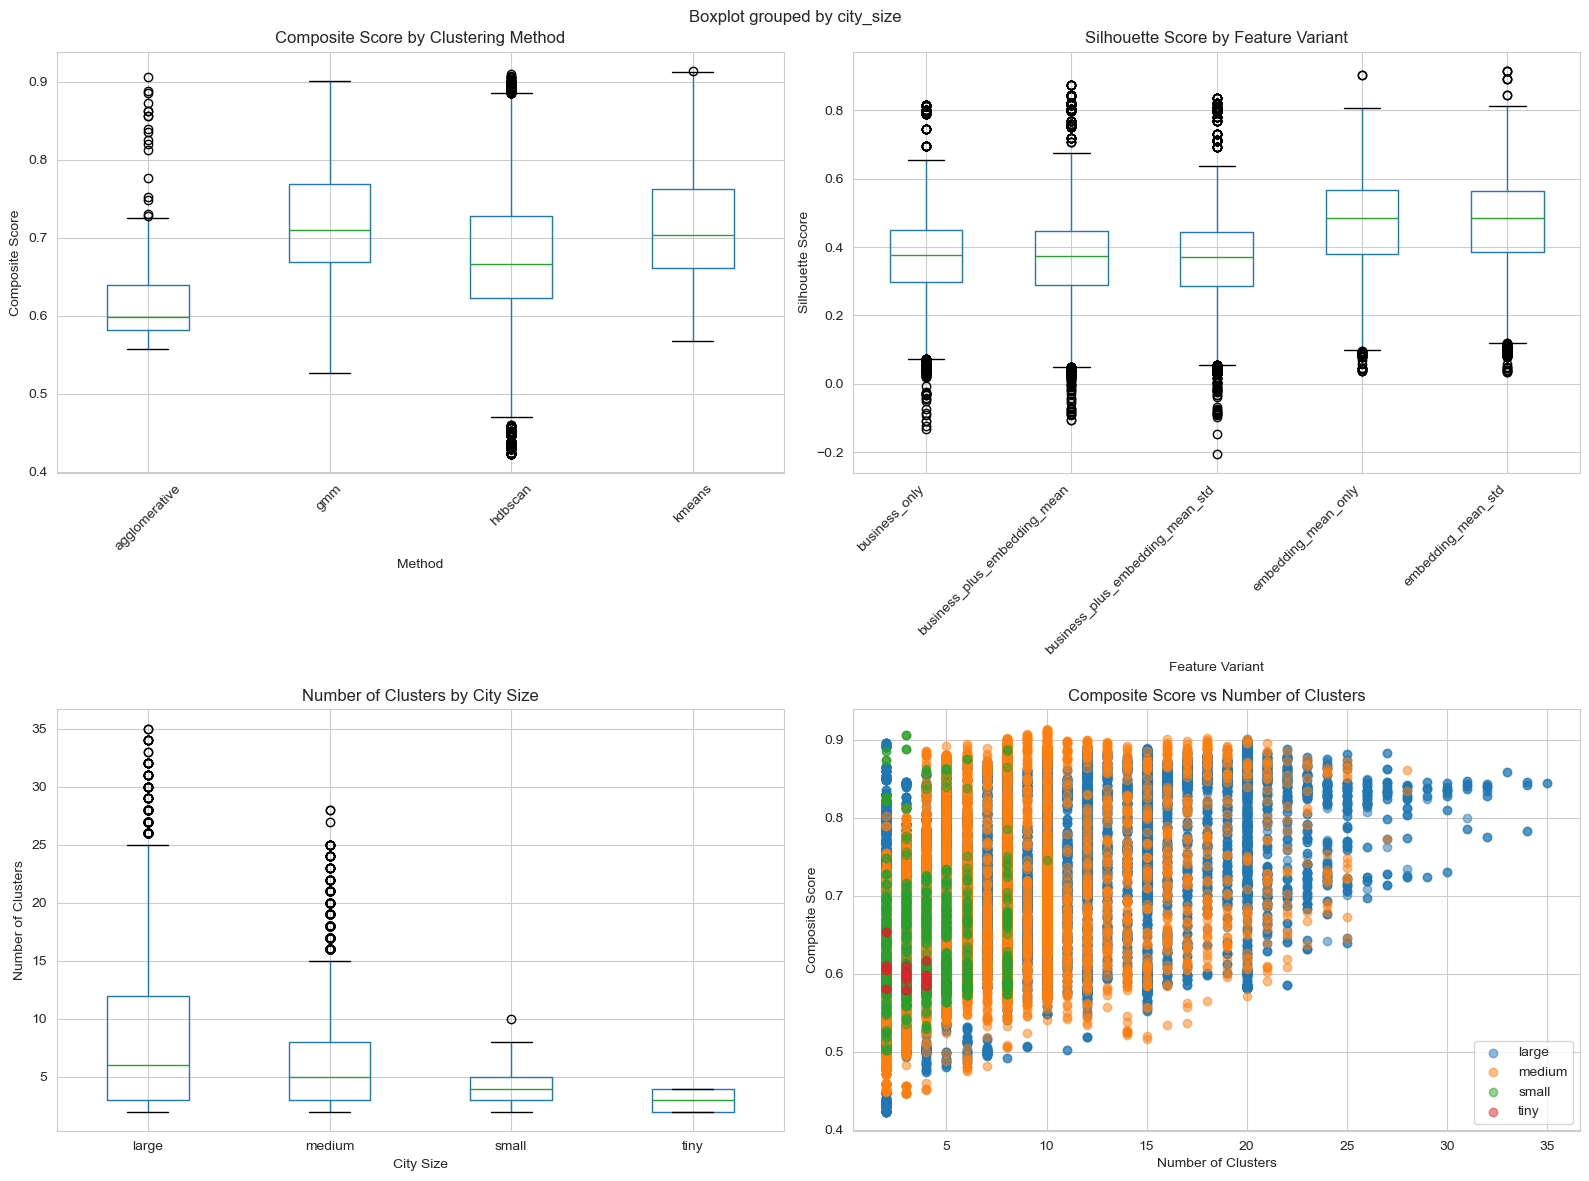


✓ Saved visualization: experiment_summary.png


In [36]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Composite scores by method
ax = axes[0, 0]
valid_results.boxplot(
    column='composite_score',
    by='clustering_method',
    ax=ax
)
ax.set_title('Composite Score by Clustering Method')
ax.set_xlabel('Method')
ax.set_ylabel('Composite Score')
plt.sca(ax)
plt.xticks(rotation=45)

# 2. Silhouette by feature variant
ax = axes[0, 1]
valid_results.boxplot(
    column='silhouette',
    by='feature_variant',
    ax=ax
)
ax.set_title('Silhouette Score by Feature Variant')
ax.set_xlabel('Feature Variant')
ax.set_ylabel('Silhouette Score')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')

# 3. Number of clusters by city size
ax = axes[1, 0]
valid_results.boxplot(
    column='n_clusters',
    by='city_size',
    ax=ax
)
ax.set_title('Number of Clusters by City Size')
ax.set_xlabel('City Size')
ax.set_ylabel('Number of Clusters')

# 4. Composite score vs n_clusters
ax = axes[1, 1]
for city_size in valid_results['city_size'].unique():
    data = valid_results[valid_results['city_size'] == city_size]
    ax.scatter(
        data['n_clusters'],
        data['composite_score'],
        alpha=0.5,
        label=city_size
    )
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Composite Score')
ax.set_title('Composite Score vs Number of Clusters')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'experiment_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization: experiment_summary.png")

In [37]:
# Print top 3 cities' best configs
print("\n" + "="*80)
print("TOP CONFIGURATIONS - SAMPLE CITIES")
print("="*80)

for city_size_cat in ['large', 'medium', 'small']:
    cities_in_cat = valid_results[valid_results['city_size'] == city_size_cat]['city'].unique()[:1]
    
    for city in cities_in_cat:
        print(f"\n{city.upper()} ({city_size_cat})")
        print("-" * 80)
        
        city_best = valid_results[
            valid_results['city'] == city
        ].nlargest(3, 'composite_score')
        
        for rank, (idx, row) in enumerate(city_best.iterrows(), 1):
            print(f"\nRank {rank}:")
            print(f"  Features: {row['feature_variant']}")
            print(f"  DimRed: {row['dimred']}")
            print(f"  Method: {row['clustering_method']}")
            print(f"  Params: {row['clustering_params']}")
            print(f"  Clusters: {row['n_clusters']}")
            print(f"  Composite: {row['composite_score']:.3f}")
            print(f"  Silhouette: {row['silhouette']:.3f}")
            print(f"  Davies-Bouldin: {row['davies_bouldin']:.3f}")
            print(f"  Noise: {row['noise_ratio']:.2%}")


TOP CONFIGURATIONS - SAMPLE CITIES

PHILADELPHIA (large)
--------------------------------------------------------------------------------

Rank 1:
  Features: embedding_mean_only
  DimRed: umap_n15_c100_d0.0_euclidean
  Method: gmm
  Params: {"n_components": 12, "covariance_type": "full"}
  Clusters: 12
  Composite: 0.892
  Silhouette: 0.579
  Davies-Bouldin: 0.612
  Noise: 0.00%

Rank 2:
  Features: embedding_mean_std
  DimRed: umap_n15_c50_d0.0_euclidean
  Method: gmm
  Params: {"n_components": 12, "covariance_type": "full"}
  Clusters: 12
  Composite: 0.892
  Silhouette: 0.576
  Davies-Bouldin: 0.604
  Noise: 0.00%

Rank 3:
  Features: embedding_mean_only
  DimRed: umap_n15_c20_d0.0_euclidean
  Method: kmeans
  Params: {"n_clusters": 10}
  Clusters: 10
  Composite: 0.891
  Silhouette: 0.616
  Davies-Bouldin: 0.510
  Noise: 0.00%

ST. LOUIS (medium)
--------------------------------------------------------------------------------

Rank 1:
  Features: embedding_mean_only
  DimRed: uma

EMPIRICAL THRESHOLD ANALYSIS

Best clustering method by city size:
 n_businesses clustering_method  composite_score
           11            kmeans         0.617432
           12            kmeans         0.653471
           28            kmeans         0.610659
           50            kmeans         0.708709
           52            kmeans         0.825903
           66            kmeans         0.873368
           67            kmeans         0.906402
           72            kmeans         0.747484
           78            kmeans         0.740427
           96            kmeans         0.785581
          100            kmeans         0.734522
          116               gmm         0.753847
          118            kmeans         0.893897
          126            kmeans         0.749534
          149            kmeans         0.767756
          276            kmeans         0.899496
          341            kmeans         0.914186
          404           hdbscan         0.899825
  

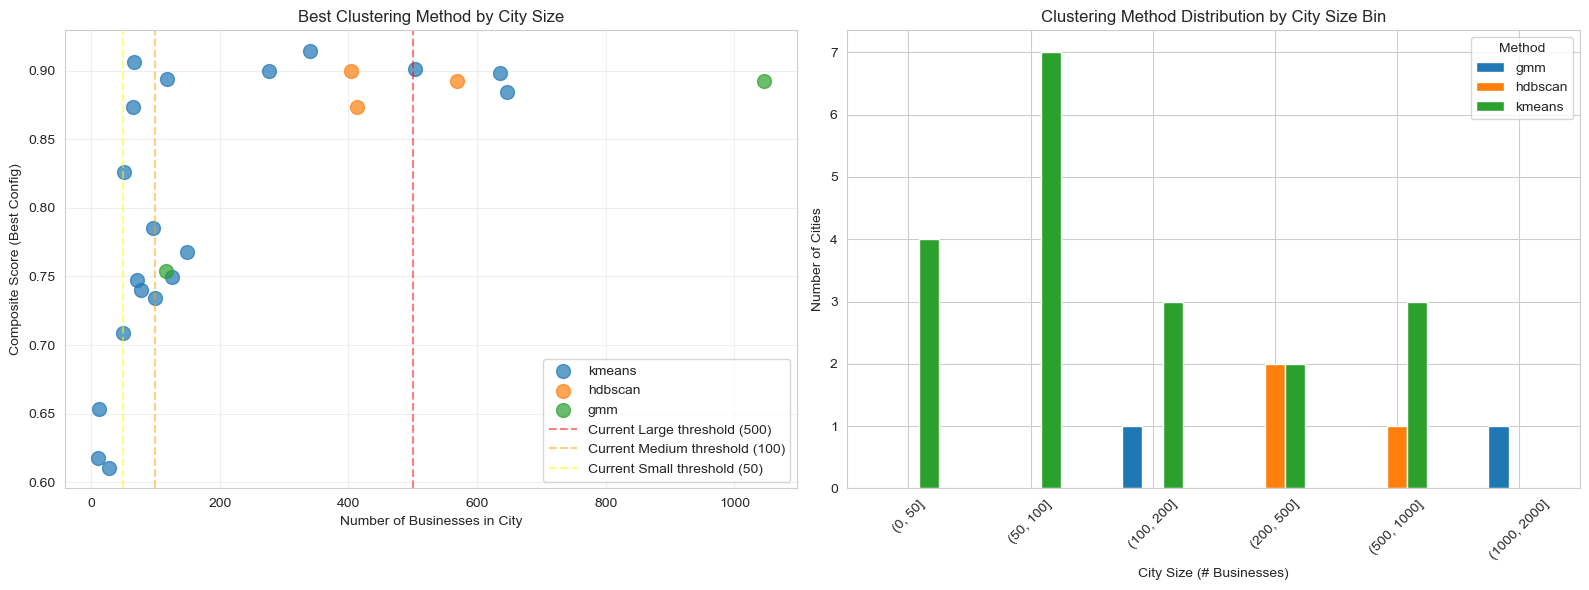


SUGGESTED OPTIMAL THRESHOLDS

HDBSCAN Performance:
  Wins in 3 cities
  Smallest city where it wins: 404 businesses
  Typical city size: 413 businesses
  → Suggested LARGE threshold: >= 408

KMeans Performance:
  Wins in 19 cities
  Largest city where it wins: 646 businesses
  Typical city size: 96 businesses
  → Suggested SMALL threshold: < 212

GMM Performance:
  Wins in 2 cities
  City size range: 116-1046
  → GMM is competitive in this range

QUALITY THRESHOLD ANALYSIS

All cities have acceptable clustering quality (>= 0.5)

FINAL RECOMMENDED THRESHOLDS

Based on experimental results:

CITY_SIZE_CONFIG = {
    'LARGE': {
        'threshold': >= 408,
        'methods': ['hdbscan', 'gmm'],
        'reasoning': 'HDBSCAN performs best for larger cities with natural density clusters'
    },
    'MEDIUM': {
        'threshold': 212-407,
        'methods': ['hdbscan', 'kmeans', 'gmm'],
        'reasoning': 'Test multiple methods, density-based and centroid-based'
    },
    'SMALL': {
  

In [38]:
# Find best method per city
best_configs = valid_results.loc[valid_results.groupby('city')['composite_score'].idxmax()].copy()

print("="*80)
print("EMPIRICAL THRESHOLD ANALYSIS")
print("="*80)

# Analyze which method wins at which city sizes
method_by_size = best_configs[['n_businesses', 'clustering_method', 'composite_score']].sort_values('n_businesses')

print("\nBest clustering method by city size:")
print(method_by_size.to_string(index=False))

# Find size ranges where each method dominates
print("\n" + "="*80)
print("METHOD DOMINANCE BY CITY SIZE")
print("="*80)

for method in best_configs['clustering_method'].unique():
    method_data = best_configs[best_configs['clustering_method'] == method]['n_businesses']
    if len(method_data) > 0:
        print(f"\n{method.upper()}:")
        print(f"  Cities where this wins: {len(method_data)}")
        print(f"  City size range: {method_data.min()}-{method_data.max()} businesses")
        print(f"  Median city size: {method_data.median():.0f} businesses")
        print(f"  25th percentile: {method_data.quantile(0.25):.0f} businesses")
        print(f"  75th percentile: {method_data.quantile(0.75):.0f} businesses")

# Visualize method transitions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scatter - method by size
ax = axes[0]
for method in best_configs['clustering_method'].unique():
    data = best_configs[best_configs['clustering_method'] == method]
    ax.scatter(data['n_businesses'], data['composite_score'], 
               label=method, alpha=0.7, s=100)

# Show current thresholds
ax.axvline(x=LARGE_CITY_THRESHOLD, color='r', linestyle='--', alpha=0.5,
           label=f'Current Large threshold ({LARGE_CITY_THRESHOLD})')
ax.axvline(x=MEDIUM_CITY_THRESHOLD, color='orange', linestyle='--', alpha=0.5,
           label=f'Current Medium threshold ({MEDIUM_CITY_THRESHOLD})')
ax.axvline(x=SMALL_CITY_THRESHOLD, color='yellow', linestyle='--', alpha=0.5,
           label=f'Current Small threshold ({SMALL_CITY_THRESHOLD})')

ax.set_xlabel('Number of Businesses in City')
ax.set_ylabel('Composite Score (Best Config)')
ax.set_title('Best Clustering Method by City Size')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Method distribution by size bins
ax = axes[1]
bins = [0, 50, 100, 200, 500, 1000, 2000]
best_configs['size_bin'] = pd.cut(best_configs['n_businesses'], bins=bins)
method_dist = best_configs.groupby(['size_bin', 'clustering_method']).size().unstack(fill_value=0)
method_dist.plot(kind='bar', stacked=False, ax=ax)
ax.set_title('Clustering Method Distribution by City Size Bin')
ax.set_xlabel('City Size (# Businesses)')
ax.set_ylabel('Number of Cities')
ax.legend(title='Method')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Suggest optimal thresholds based on empirical data
print("\n" + "="*80)
print("SUGGESTED OPTIMAL THRESHOLDS")
print("="*80)

# Find where HDBSCAN becomes consistently best (if it does)
hdbscan_cities = best_configs[best_configs['clustering_method'] == 'hdbscan']
kmeans_cities = best_configs[best_configs['clustering_method'] == 'kmeans']
gmm_cities = best_configs[best_configs['clustering_method'] == 'gmm']

if len(hdbscan_cities) > 0:
    hdbscan_min = hdbscan_cities['n_businesses'].min()
    hdbscan_median = hdbscan_cities['n_businesses'].median()
    print(f"\nHDBSCAN Performance:")
    print(f"  Wins in {len(hdbscan_cities)} cities")
    print(f"  Smallest city where it wins: {hdbscan_min} businesses")
    print(f"  Typical city size: {hdbscan_median:.0f} businesses")
    print(f"  → Suggested LARGE threshold: >= {int(hdbscan_cities['n_businesses'].quantile(0.25))}")
else:
    print("\nHDBSCAN: Not the best method for any city in this dataset")

if len(kmeans_cities) > 0:
    kmeans_max = kmeans_cities['n_businesses'].max()
    kmeans_median = kmeans_cities['n_businesses'].median()
    print(f"\nKMeans Performance:")
    print(f"  Wins in {len(kmeans_cities)} cities")
    print(f"  Largest city where it wins: {kmeans_max} businesses")
    print(f"  Typical city size: {kmeans_median:.0f} businesses")
    print(f"  → Suggested SMALL threshold: < {int(kmeans_cities['n_businesses'].quantile(0.75))}")
else:
    print("\nKMeans: Not the best method for any city in this dataset")

if len(gmm_cities) > 0:
    print(f"\nGMM Performance:")
    print(f"  Wins in {len(gmm_cities)} cities")
    print(f"  City size range: {gmm_cities['n_businesses'].min()}-{gmm_cities['n_businesses'].max()}")
    print(f"  → GMM is competitive in this range")

# Quality threshold analysis
print("\n" + "="*80)
print("QUALITY THRESHOLD ANALYSIS")
print("="*80)

# Find where clustering quality drops below acceptable
quality_threshold = 0.5  # Adjust based on your needs

poor_quality_cities = best_configs[best_configs['composite_score'] < quality_threshold]
if len(poor_quality_cities) > 0:
    print(f"\nCities with poor clustering quality (composite < {quality_threshold}):")
    print(f"  Count: {len(poor_quality_cities)}")
    print(f"  Size range: {poor_quality_cities['n_businesses'].min()}-{poor_quality_cities['n_businesses'].max()}")
    print(f"  Median size: {poor_quality_cities['n_businesses'].median():.0f}")
    print(f"\n  → Consider RULE-BASED segmentation for cities with < {int(poor_quality_cities['n_businesses'].quantile(0.75))} businesses")
else:
    print(f"\nAll cities have acceptable clustering quality (>= {quality_threshold})")

# Final recommendations
print("\n" + "="*80)
print("FINAL RECOMMENDED THRESHOLDS")
print("="*80)

# Calculate data-driven thresholds
recommendations = {}

if len(hdbscan_cities) > 0:
    recommendations['LARGE'] = int(hdbscan_cities['n_businesses'].quantile(0.25))
    recommendations['LARGE_METHODS'] = ['hdbscan', 'gmm']
else:
    recommendations['LARGE'] = LARGE_CITY_THRESHOLD
    recommendations['LARGE_METHODS'] = ['kmeans', 'gmm']

if len(kmeans_cities) > 0:
    recommendations['SMALL'] = int(kmeans_cities['n_businesses'].quantile(0.75))
    recommendations['SMALL_METHODS'] = ['kmeans', 'agglomerative']
else:
    recommendations['SMALL'] = SMALL_CITY_THRESHOLD
    recommendations['SMALL_METHODS'] = ['kmeans']

recommendations['MEDIUM'] = (recommendations['SMALL'] + recommendations['LARGE']) // 2
recommendations['MEDIUM_METHODS'] = ['hdbscan', 'kmeans', 'gmm']

if len(poor_quality_cities) > 0:
    recommendations['TINY'] = int(poor_quality_cities['n_businesses'].quantile(0.75))
    recommendations['TINY_METHODS'] = ['rule-based']
else:
    recommendations['TINY'] = SMALL_CITY_THRESHOLD // 2
    recommendations['TINY_METHODS'] = ['kmeans']

print("\nBased on experimental results:")
print(f"""
CITY_SIZE_CONFIG = {{
    'LARGE': {{
        'threshold': >= {recommendations['LARGE']},
        'methods': {recommendations['LARGE_METHODS']},
        'reasoning': 'HDBSCAN performs best for larger cities with natural density clusters'
    }},
    'MEDIUM': {{
        'threshold': {recommendations['SMALL']}-{recommendations['LARGE']-1},
        'methods': {recommendations['MEDIUM_METHODS']},
        'reasoning': 'Test multiple methods, density-based and centroid-based'
    }},
    'SMALL': {{
        'threshold': {recommendations['TINY']}-{recommendations['SMALL']-1},
        'methods': {recommendations['SMALL_METHODS']},
        'reasoning': 'KMeans works well when sample size limits density estimation'
    }},
    'TINY': {{
        'threshold': < {recommendations['TINY']},
        'methods': {recommendations['TINY_METHODS']},
        'reasoning': 'Too few samples for robust ML clustering'
    }}
}}
""")

# Save recommendations
threshold_config = {
    'original_thresholds': {
        'LARGE': LARGE_CITY_THRESHOLD,
        'MEDIUM': MEDIUM_CITY_THRESHOLD,
        'SMALL': SMALL_CITY_THRESHOLD
    },
    'recommended_thresholds': recommendations,
    'analysis': {
        'total_cities_tested': len(best_configs),
        'method_distribution': best_configs['clustering_method'].value_counts().to_dict(),
        'avg_composite_scores_by_method': best_configs.groupby('clustering_method')['composite_score'].mean().to_dict()
    }
}

with open(OUTPUT_DIR / 'optimal_thresholds.json', 'w') as f:
    json.dump(threshold_config, f, indent=2)

print(f"\n✓ Saved threshold analysis to: {OUTPUT_DIR / 'optimal_thresholds.json'}")
print(f"✓ Saved visualization to: {OUTPUT_DIR / 'threshold_analysis.png'}")

---
# PHASE 9: Empirical Threshold Analysis

## Discover Optimal City Size Thresholds from Data